### Модели классификации

#### Цель работы

Познакомиться с основными приемами работы с моделями классификации в scikit-learn.

#### Задания для выполнения

1. Загрузите [данные](https://www.kaggle.com/uciml/pima-indians-diabetes-database) о диагностике сахарного диабета.
3. Постройте модель классификации для предсказания наличия заболевания.
4. Оцените качество построенной модели с помощью отчета о классификации и матрицы классификации.
5. Постройте альтернативную полиномиальную модель, сравните ее с предыдущей.


### Методические указания

Для начала работы обратимся к набору данных diabetes. Это довольно известный датасет, собравший информацию о медицинских показателях более 700 пациентов, обследованных на предмет наличия сахарного диабета. На нем мы потренируемся строить классификационные модели.

Сперва загрузим исходный набор данных. Это можно сделать, как скопировав файл csv в локальную папку, так и по общедоступному URL:


In [2]:
import pandas as pd
data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML2.2%20real%20classification/data/diabetes.csv")

Обратите внимание, что в библиотеке sklearn встроен очень похожий датасет pima-indian-diabetes. Имейте в виду, что в данной работе используется немного другой датасет.

Как и ранее, хорошей идеей перед началом анализа будет познакомиться с составом набора данных визуально. Выведем датасет на экран:

In [3]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


При проведении серьезного анализа перед построением модели машинного обучения нужно провести тщательную обработку и очистку набора данных - удаление пропущенных значений, анализ шкал, нормализация, удаление выбросов и аномалий. В учебных целях ограничимся обязательными проверками критических ошибок в данных.

В первую очередь проверим данные на наличие пропущенных значений:

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Видим, что пропусков в данных нет. Кроме того, видно, что все данные выражены в численных шкалах. Значит, особенной обработки данный датасет не требует, он уже достаточно чистый. Теперь можно вывести основную статистику по датасету:

In [6]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Здесь мы видим шкалу измерения каждого признака. Можно придти к выводу, что явных видимых аномалий в данных нет. отдельно обратим внимание на столбец "Outcome" - он содержит целевую переменную. В данном случае она также выражается числом (0 - здоров, 1 - болен), но это не всегда так.

Теперь выделим целевую переменную и факторы:

In [7]:
y = data.Outcome
X = data.drop(["Outcome"], axis=1)

Выведем форму получившихся массивов:

In [8]:
y.shape, X.shape

((768,), (768, 8))

Данные выглядят полностью готовыми к началу машинного обучения. Для начала импортируем нужный класс и создадим его экземпляр:

In [9]:
from sklearn.linear_model import LogisticRegression
logistic = LogisticRegression()

Обучим созданную модель на имеющихся у нас данных:

После выполнения этой инструкции мы можем увидеть специальное предупреждение:

In [10]:
logistic.fit(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

Смысл этого сообщения в том, что процесс обучения завершился по условию достижения максимального количества итераций, а не по условию стабилизации функции ошибки. Это значит, что модель обучается трудно и медленно. Это может свидетельствовать о том, что результаты могут быть не очень удовлетворительными.

Но давайте посмотрим, что за модель мы получили после такого обучения. В первую очередь выведем коэффициенты модели:

In [11]:
print("Coefficients: \n", logistic.coef_[0])

Coefficients: 
 [ 1.17252348e-01  3.36001424e-02 -1.40872986e-02 -1.27037878e-03
 -1.24033826e-03  7.72020114e-02  1.41904264e+00  1.00350891e-02]


В линейных моделях коэффициенты имеют физический смысл - они показывают значимость соответствующих признаков. Поэтому представляет особый интерес посмотреть коэффициенты вместе с названиями признаков.

Для этого соединим массив названий колонок из датасета и массив коэффициентов. Можно использовать, например, генераторное выражение для прохода по получившемуся массиву. Конструкция "_ = [ ... ]" нужна только в ноутбуке для того, чтобы подавить автоматический вывод выражения:

In [12]:
_ = [print(k, v) for k, v in zip(X.columns, logistic.coef_[0])]

Pregnancies 0.11725234808012788
Glucose 0.033600142398877694
BloodPressure -0.014087298647387265
SkinThickness -0.0012703787783052332
Insulin -0.0012403382628561567
BMI 0.07720201139735491
DiabetesPedigreeFunction 1.419042642437566
Age 0.0100350890899355


Самостоятельно проанализируйте эти данные и сделайте вывод, какие атрибуты оказывают большее влияние на значение целевой переменной.

Как и в модели линейной регрессии, данный вектор не включает в себя свободный коэффициент. Он хранится в отдельном поле класса:

In [13]:
print("Intercept: \n", logistic.intercept_)

Intercept: 
 [-7.702939]


Теперь можно построить по полученной модели прогноз. Для этого передадим в соответствующий метод нашу матрицу признаков:

In [14]:
y_pred = logistic.predict(X)

Сформировав вектор предсказанных значений целевой переменной можно сравнить его с реальными значениями:

In [15]:
_ = [print(a, b) for a, b in list(zip(y, y_pred))[:10]]

1 1
0 0
1 1
0 0
1 1
0 0
1 0
0 1
1 1
1 0


Можно видеть, что большинство значений совпадает, но есть и ошибки - различия в значениях. Но так сравнивать все значения в ручном режиме очень неудобно. Поэтому лучше использовать специальные функции - метрики. Самая простая из них подсчитывает количество правильно и неправильно распознанных объектов и представляет результат в виде матрицы классификации:

In [16]:
from sklearn import metrics
metrics.confusion_matrix(y, y_pred)

array([[447,  53],
       [114, 154]])

Матрица классификации показывает нам очень полезную информацию: совместное распределение числа объектов предсказанных и реальных классов. Рассматривая эту матрицу мы можем получить важную информацию: сколько объектов мы классифицировали правильно, сколько неверно, к каким классам наша модель тяготеет, какие классы распознаются хорошо, какие - плохо

Гораздо удобнее анализировать ту же информацию в графической форме. Для этого воспользуемся специальной библиотекой seaborn, которая позволяет создавать полезные для машинного обучения визуализации очень просто:

<Axes: >

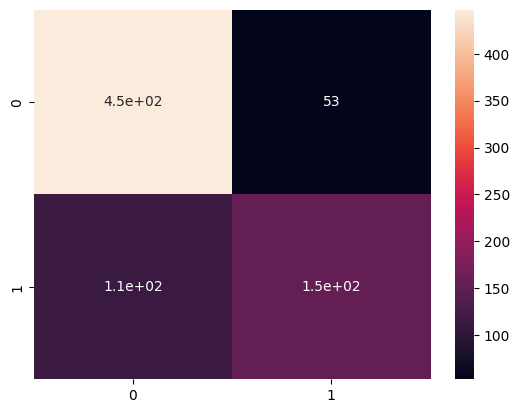

In [17]:
import seaborn as sns
sns.heatmap(metrics.confusion_matrix(y, y_pred), annot=True)

Кроме матрицы классификации весьма полезно использовать численные метрики эффективности классификации. Самая простая и распространенная из них - метрика точности предсказания - показывает долю правильно распознанных объектов. Расчет этой метрики встроен в сам объект модели и доступен с помощью специального метода:

In [18]:
logistic.score(X, y)

0.7825520833333334

Эту же метрику можно рассчитать и по-другому - через отдельную функцию из пакета metrics. Обратите внимание на другую сигнатуру метода:

In [20]:
metrics.accuracy_score(y, y_pred)

0.7825520833333334

Значение метрики (0,78) показывает, что модель в среднем делает ошибки в 22% процентов случаев. Это основной показатель качества модели. В дальнейших работах мы покажем, как его замерять более правильно.

Если же такой уровень эффективности нас не устраивает, то мы можем попробовать использовать другие классы моделей классификации и среди них выбрать наиболее качественную. Например, можно попробовать построить полиномиальную модель. В библиотеке sklearn не предусмотрено отдельного класса полиномиальной модели. Ее можно создать через специальный объект PolynomialFeature, который добавляет полиномиальные признаки к данным. Для его использования сначала импортируем его:

In [21]:
from sklearn.preprocessing import PolynomialFeatures

Теперь можно создать объект преобразования (точно также как мы создавали объект модели):

In [22]:
poly = PolynomialFeatures(2)

Здесь мы указываем, что будем создавать полиномиальные признаки второго порядка. Теперь можно использовать этот объект для создания собственно самих признаков:

In [23]:
poly = poly.fit_transform(X)
poly

array([[1.00000e+00, 6.00000e+00, 1.48000e+02, ..., 3.93129e-01,
        3.13500e+01, 2.50000e+03],
       [1.00000e+00, 1.00000e+00, 8.50000e+01, ..., 1.23201e-01,
        1.08810e+01, 9.61000e+02],
       [1.00000e+00, 8.00000e+00, 1.83000e+02, ..., 4.51584e-01,
        2.15040e+01, 1.02400e+03],
       ...,
       [1.00000e+00, 5.00000e+00, 1.21000e+02, ..., 6.00250e-02,
        7.35000e+00, 9.00000e+02],
       [1.00000e+00, 1.00000e+00, 1.26000e+02, ..., 1.21801e-01,
        1.64030e+01, 2.20900e+03],
       [1.00000e+00, 1.00000e+00, 9.30000e+01, ..., 9.92250e-02,
        7.24500e+00, 5.29000e+02]])

Теперь эти данные можно использовать как исходные для моделирования. А строить мы будем обычную логистическую регрессию:

In [24]:
polynomial = LogisticRegression()
polynomial.fit(poly, y)
y_pred_poly = polynomial.predict(poly)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [27]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Линейная модель (уже обучена)
y_pred_linear = logistic.predict(X)
acc_linear = accuracy_score(y, y_pred_linear)
print("Линейная модель LogisticRegression")
print(f"Accuracy: {acc_linear:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y, y_pred_linear))
print("Classification Report:\n", classification_report(y, y_pred_linear))

Линейная модель LogisticRegression
Accuracy: 0.7826
Confusion Matrix:
 [[447  53]
 [114 154]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.89      0.84       500
           1       0.74      0.57      0.65       268

    accuracy                           0.78       768
   macro avg       0.77      0.73      0.75       768
weighted avg       0.78      0.78      0.77       768



In [28]:
# Полиномиальная модель (обучим заново для чистоты эксперимента)
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(2)
X_poly = poly.fit_transform(X)

In [30]:
polynomial = LogisticRegression(max_iter=1000)  # увеличим итерации для сходимости
polynomial.fit(X_poly, y)
y_pred_poly = polynomial.predict(X_poly)

acc_poly = accuracy_score(y, y_pred_poly)
print("\nПолиномиальная модель (степень 2)")
print(f"Accuracy: {acc_poly:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y, y_pred_poly))
print("Classification Report:\n", classification_report(y, y_pred_poly))


Полиномиальная модель (степень 2)
Accuracy: 0.7904
Confusion Matrix:
 [[457  43]
 [118 150]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.91      0.85       500
           1       0.78      0.56      0.65       268

    accuracy                           0.79       768
   macro avg       0.79      0.74      0.75       768
weighted avg       0.79      0.79      0.78       768



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
# Сравнение
print("\nСравнение точности:")
print(f"Линейная модель: {acc_linear:.4f}")
print(f"Полиномиальная модель: {acc_poly:.4f}")


Сравнение точности:
Линейная модель: 0.7826
Полиномиальная модель: 0.7904


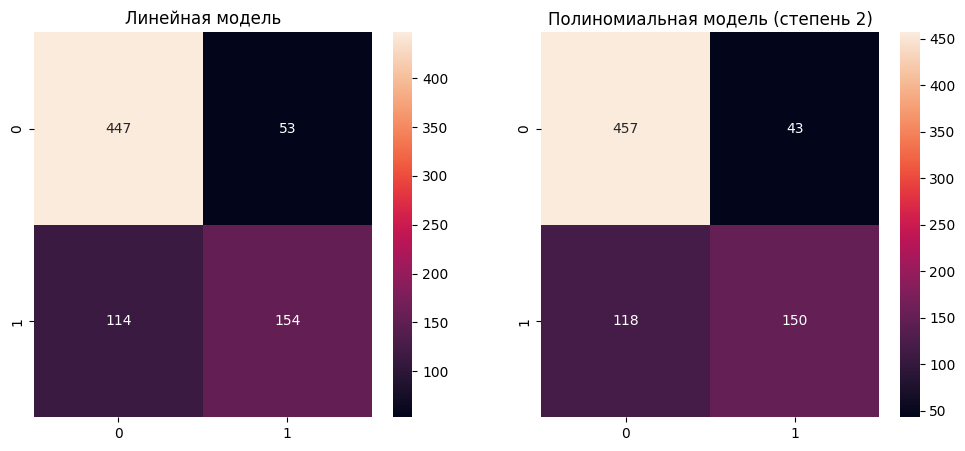

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y, y_pred_linear), annot=True, fmt='d', ax=axes[0])
axes[0].set_title('Линейная модель')

sns.heatmap(confusion_matrix(y, y_pred_poly), annot=True, fmt='d', ax=axes[1])
axes[1].set_title('Полиномиальная модель (степень 2)')

plt.show()

#### Задания для самостоятельного выполнения

1. Изучите документацию _sklearn_, посвященную классу [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html). Какую еще информацию можно вывести для обученной модели? Попробуйте изменить аргументы при создании модели и посмотрите, как это влияет на качество предсказания.


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Обучим модель с увеличенным числом итераций и другим solver'ом
model_tuned = LogisticRegression(max_iter=2000, solver='lbfgs')
model_tuned.fit(X, y)
y_pred_tuned = model_tuned.predict(X)
acc_tuned = accuracy_score(y, y_pred_tuned)
print(f"Accuracy (max_iter=2000): {acc_tuned:.4f}")
print(f"Число итераций для сходимости: {model_tuned.n_iter_[0]}")

# добавил C
model_tuned = LogisticRegression(max_iter=2000, solver='lbfgs', C=0.1)
model_tuned.fit(X, y)
y_pred_tuned = model_tuned.predict(X)
acc_tuned = accuracy_score(y, y_pred_tuned)
print(f"Accuracy (max_iter=2000): {acc_tuned:.4f}")
print(f"Число итераций для сходимости: {model_tuned.n_iter_[0]}")

Accuracy (max_iter=2000): 0.7812
Число итераций для сходимости: 200
Accuracy (max_iter=2000): 0.7734
Число итераций для сходимости: 135


**Вывод по эксперименту с параметрами LogisticRegression:**

- Увеличение `max_iter` до 2000 позволило алгоритму сойтись (ранее было предупреждение о достижении лимита итераций). Для первой модели (`C=1.0`) потребовалось 200 итераций, для второй (`C=0.1`) – 135.
- Параметр регуляризации `C` влияет на точность на обучающих данных: при `C=1.0` (слабая регуляризация) accuracy составила 0.7812, при `C=0.1` (более сильная регуляризация) accuracy снизилась до 0.7734. Это ожидаемо, так как усиление регуляризации упрощает модель, что может уменьшить переобучение, но на обучающей выборке точность обычно падает.
- Количество итераций для сходимости также уменьшилось при более сильной регуляризации, что может быть связано с более гладкой функцией потерь.

Таким образом, подбор гиперпараметров (особенно `C` и `max_iter`) позволяет управлять процессом обучения и качеством модели. Для более объективной оценки необходимо проверять модель на отложенной выборке или с помощью кросс-валидации.

2. Попробуйте применить к той же задаче другие модели классификации. Для каждой из них выведите матрицу классификации и оценку точности. Рекомендуется исследовать следующие модели:
    1. Метод опорных векторов
        1. Без ядра
        2. С линейным ядром
        3. С гауссовым ядром
        4. С полиномиальным ядром
    2. Метод ближайших соседей
    3. Многослойный перцептрон
    4. Дерево решений
    5. Наивный байесовский классификатор
    6. (\*) Другие методы:
        1. Пассивно-агрессивный классификатор
        2. Гребневый классификатор
        3. Случайный лес
        4. Беггинг
        5. Другие модели по желанию


In [42]:
# 1.1 Линейный SVM (без ядра или с линейным ядром)
from sklearn.svm import SVC

svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X, y)
y_pred_svm_lin = svm_linear.predict(X)
acc_svm_lin = accuracy_score(y, y_pred_svm_lin)
print("SVM (linear kernel)")
print(f"Accuracy: {acc_svm_lin:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y, y_pred_svm_lin))
print()

# 1.2 SVM с гауссовым (RBF) ядром
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X, y)
y_pred_svm_rbf = svm_rbf.predict(X)
acc_svm_rbf = accuracy_score(y, y_pred_svm_rbf)
print("SVM (RBF kernel)")
print(f"Accuracy: {acc_svm_rbf:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y, y_pred_svm_rbf))
print()

# 1.3 SVM с полиномиальным ядром (степень 3 по умолчанию)
svm_poly = SVC(kernel='poly', degree=3, random_state=42)
svm_poly.fit(X, y)
y_pred_svm_poly = svm_poly.predict(X)
acc_svm_poly = accuracy_score(y, y_pred_svm_poly)
print("SVM (poly kernel, degree=3)")
print(f"Accuracy: {acc_svm_poly:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y, y_pred_svm_poly))
print()

# 2. Метод ближайших соседей (KNN)
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, y)
y_pred_knn = knn.predict(X)
acc_knn = accuracy_score(y, y_pred_knn)
print("KNN (k=5)")
print(f"Accuracy: {acc_knn:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y, y_pred_knn))
print()

# 3. Многослойный перцептрон (MLP)
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
mlp.fit(X, y)
y_pred_mlp = mlp.predict(X)
acc_mlp = accuracy_score(y, y_pred_mlp)
print("MLP (1 hidden layer, 100 neurons)")
print(f"Accuracy: {acc_mlp:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y, y_pred_mlp))
print()

# 4. Дерево решений
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X, y)
y_pred_tree = tree.predict(X)
acc_tree = accuracy_score(y, y_pred_tree)
print("Decision Tree")
print(f"Accuracy: {acc_tree:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y, y_pred_tree))
print()

# 5. Наивный байесовский классификатор (гауссов)
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X, y)
y_pred_nb = nb.predict(X)
acc_nb = accuracy_score(y, y_pred_nb)
print("Gaussian Naive Bayes")
print(f"Accuracy: {acc_nb:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y, y_pred_nb))
print()

# 6. Дополнительные методы

# 6.1 Пассивно-агрессивный классификатор
from sklearn.linear_model import PassiveAggressiveClassifier

pa = PassiveAggressiveClassifier(max_iter=1000, random_state=42)
pa.fit(X, y)
y_pred_pa = pa.predict(X)
acc_pa = accuracy_score(y, y_pred_pa)
print("Passive Aggressive")
print(f"Accuracy: {acc_pa:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y, y_pred_pa))
print()

# 6.2 Гребневый классификатор (RidgeClassifier)
from sklearn.linear_model import RidgeClassifier

ridge = RidgeClassifier()
ridge.fit(X, y)
y_pred_ridge = ridge.predict(X)
acc_ridge = accuracy_score(y, y_pred_ridge)
print("Ridge Classifier")
print(f"Accuracy: {acc_ridge:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y, y_pred_ridge))
print()

# 6.3 Случайный лес
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
y_pred_rf = rf.predict(X)
acc_rf = accuracy_score(y, y_pred_rf)
print("Random Forest")
print(f"Accuracy: {acc_rf:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y, y_pred_rf))
print()

# 6.4 Беггинг (Bagging) на основе дерева решений
from sklearn.ensemble import BaggingClassifier

bagging = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)
bagging.fit(X, y)
y_pred_bag = bagging.predict(X)
acc_bag = accuracy_score(y, y_pred_bag)
print("Bagging (with Decision Tree)")
print(f"Accuracy: {acc_bag:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y, y_pred_bag))
print()

SVM (linear kernel)
Accuracy: 0.7773
Confusion Matrix:
 [[443  57]
 [114 154]]

SVM (RBF kernel)
Accuracy: 0.7682
Confusion Matrix:
 [[457  43]
 [135 133]]

SVM (poly kernel, degree=3)
Accuracy: 0.7760
Confusion Matrix:
 [[465  35]
 [137 131]]

KNN (k=5)
Accuracy: 0.8034
Confusion Matrix:
 [[442  58]
 [ 93 175]]

MLP (1 hidden layer, 100 neurons)
Accuracy: 0.7279
Confusion Matrix:
 [[459  41]
 [168 100]]

Decision Tree
Accuracy: 1.0000
Confusion Matrix:
 [[500   0]
 [  0 268]]

Gaussian Naive Bayes
Accuracy: 0.7630
Confusion Matrix:
 [[421  79]
 [103 165]]

Passive Aggressive
Accuracy: 0.4609
Confusion Matrix:
 [[204 296]
 [118 150]]

Ridge Classifier
Accuracy: 0.7826
Confusion Matrix:
 [[447  53]
 [114 154]]

Random Forest
Accuracy: 1.0000
Confusion Matrix:
 [[500   0]
 [  0 268]]

Bagging (with Decision Tree)
Accuracy: 1.0000
Confusion Matrix:
 [[500   0]
 [  0 268]]



### Вывод по заданию 2 (сравнение моделей классификации)

Было исследовано 11 моделей классификации на наборе данных diabetes (768 объектов, 8 признаков). Оценка проводилась на всей обучающей выборке, что даёт представление о способности моделей запоминать данные, но не гарантирует качество на новых примерах.

**Основные результаты:**

- **Наилучшую точность на обучающих данных** показали модели, способные к сильному переобучению: дерево решений, случайный лес и беггинг (accuracy = 1.0). Они идеально запомнили все объекты, что делает их непригодными для реального применения без контроля сложности.
- Среди моделей, не склонных к полному запоминанию, лучший результат продемонстрировал **KNN (k=5) с accuracy 0.803**. Он допустил 93 ошибки второго рода (пропущенные больные) и 58 ложных тревог.
- Линейные модели (SVM linear, LogisticRegression, RidgeClassifier) показали стабильные значения accuracy в диапазоне 0.777–0.782.
- SVM с нелинейными ядрами (RBF, полиномиальное) не превзошли линейный вариант, что говорит о примерно линейной разделимости данных.
- **Пассивно-агрессивный классификатор** показал аномально низкий результат (0.461), вероятно, из-за неподходящих гиперпараметров или необходимости масштабирования признаков.
- Многослойный перцептрон (MLP) с одним скрытым слоем дал accuracy 0.728, что ниже простых методов – возможно, сеть не сошлась к оптимуму за 1000 итераций или требует настройки архитектуры.
- Наивный байесовский классификатор (0.763) оказался на уровне простых линейных моделей.

**Общие замечания:**
- Полученные оценки завышены, так как модели тестировались на тех же данных, на которых обучались. Для объективного сравнения необходимо использовать кросс-валидацию или разделение на train/test.
- Многие модели (особенно SVM, MLP, PassiveAggressive) чувствительны к масштабу признаков. Нормализация данных может существенно улучшить их качество.
- KNN оказался наиболее эффективным без предварительной обработки, но при масштабировании он также может стать лучше.

Таким образом, для данной задачи рекомендуется использовать KNN или линейные модели после соответствующей настройки, а деревья и ансамбли – с обязательным контролем переобучения (ограничение глубины, числа деревьев и т.д.).

3. Напишите функцию, которая автоматически обучает все перечисленные модели и для каждой выдает оценку точности.


In [43]:
def evaluate_models(X, y, random_state=42):
    """
    Обучает все модели классификации из списка и выводит accuracy на обучающей выборке.

    Parameters:
    X : array-like, shape (n_samples, n_features)
        Признаки.
    y : array-like, shape (n_samples,)
        Целевая переменная.
    random_state : int, optional
        Фиксатор случайности для воспроизводимости.

    Returns:
    dict : словарь с названиями моделей и их accuracy.
    """

    models = {
        'SVM (linear)': SVC(kernel='linear', random_state=random_state),
        'SVM (RBF)': SVC(kernel='rbf', random_state=random_state),
        'SVM (poly, deg=3)': SVC(kernel='poly', degree=3, random_state=random_state),
        'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
        'MLP (1 layer, 100)': MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=random_state),
        'Decision Tree': DecisionTreeClassifier(random_state=random_state),
        'Naive Bayes': GaussianNB(),
        'Passive Aggressive': PassiveAggressiveClassifier(max_iter=1000, random_state=random_state),
        'Ridge Classifier': RidgeClassifier(),
        'Random Forest (100 trees)': RandomForestClassifier(n_estimators=100, random_state=random_state),
        'Bagging (50 trees)': BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=random_state)
    }

    results = {}
    print("Результаты обучения моделей на всей выборке:\n")
    for name, model in models.items():
        model.fit(X, y)
        y_pred = model.predict(X)
        acc = accuracy_score(y, y_pred)
        results[name] = acc
        print(f"{name:30} : Accuracy = {acc:.4f}")

    return results

In [44]:
results = evaluate_models(X, y)

Результаты обучения моделей на всей выборке:

SVM (linear)                   : Accuracy = 0.7773
SVM (RBF)                      : Accuracy = 0.7682
SVM (poly, deg=3)              : Accuracy = 0.7760
KNN (k=5)                      : Accuracy = 0.8034
MLP (1 layer, 100)             : Accuracy = 0.7279
Decision Tree                  : Accuracy = 1.0000
Naive Bayes                    : Accuracy = 0.7630
Passive Aggressive             : Accuracy = 0.4609
Ridge Classifier               : Accuracy = 0.7826
Random Forest (100 trees)      : Accuracy = 1.0000
Bagging (50 trees)             : Accuracy = 1.0000


4. Повторите полностью анализ для другой задачи - распознавание вида ириса по параметрам растения (можно использовать метод sklearn.datasets.load_iris()).

In [46]:
from sklearn.datasets import load_iris


# Загружаем данные
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print("Размерность X:", X.shape)
print("Целевые классы:", target_names)
print("Первые 5 объектов:\n", X[:5])

Размерность X: (150, 4)
Целевые классы: ['setosa' 'versicolor' 'virginica']
Первые 5 объектов:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [47]:
# Обучаем модель (для многоклассовой задачи по умолчанию используется softmax)
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X, y)
y_pred = logreg.predict(X)

In [48]:
# Метрики
acc = accuracy_score(y, y_pred)
print(f"Accuracy (линейная): {acc:.4f}")
print("\nМатрица ошибок:\n", confusion_matrix(y, y_pred))
print("\nОтчёт о классификации:\n", classification_report(y, y_pred, target_names=target_names))

Accuracy (линейная): 0.9733

Матрица ошибок:
 [[50  0  0]
 [ 0 47  3]
 [ 0  1 49]]

Отчёт о классификации:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.98      0.94      0.96        50
   virginica       0.94      0.98      0.96        50

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



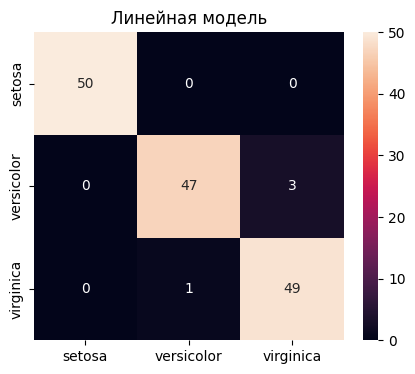

In [49]:
# Визуализация матрицы ошибок
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y, y_pred), annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names)
plt.title('Линейная модель')
plt.show()

In [50]:
# Создаём полиномиальные признаки
poly = PolynomialFeatures(degree=2, include_bias=False)  # bias не нужен, логистическая регрессия добавит сама
X_poly = poly.fit_transform(X)

print("Число признаков после полиномиализации:", X_poly.shape[1])

Число признаков после полиномиализации: 14


In [51]:
# Обучаем логистическую регрессию на расширенных признаках
logreg_poly = LogisticRegression(max_iter=2000)
logreg_poly.fit(X_poly, y)
y_pred_poly = logreg_poly.predict(X_poly)

acc_poly = accuracy_score(y, y_pred_poly)
print(f"Accuracy (полиномиальная): {acc_poly:.4f}")
print("\nМатрица ошибок (полиномиальная):\n", confusion_matrix(y, y_pred_poly))
print("\nОтчёт о классификации (полиномиальная):\n", classification_report(y, y_pred_poly, target_names=target_names))


Accuracy (полиномиальная): 0.9800

Матрица ошибок (полиномиальная):
 [[50  0  0]
 [ 0 48  2]
 [ 0  1 49]]

Отчёт о классификации (полиномиальная):
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.98      0.96      0.97        50
   virginica       0.96      0.98      0.97        50

    accuracy                           0.98       150
   macro avg       0.98      0.98      0.98       150
weighted avg       0.98      0.98      0.98       150



In [52]:
# Сравнение
print(f"\nСравнение accuracy: линейная {acc:.4f} vs полиномиальная {acc_poly:.4f}")


Сравнение accuracy: линейная 0.9733 vs полиномиальная 0.9800


In [53]:
# Используем ту же функцию, что и для diabetes
results_iris = evaluate_models(X, y)

Результаты обучения моделей на всей выборке:

SVM (linear)                   : Accuracy = 0.9933
SVM (RBF)                      : Accuracy = 0.9733
SVM (poly, deg=3)              : Accuracy = 0.9733
KNN (k=5)                      : Accuracy = 0.9667
MLP (1 layer, 100)             : Accuracy = 0.9800
Decision Tree                  : Accuracy = 1.0000
Naive Bayes                    : Accuracy = 0.9600
Passive Aggressive             : Accuracy = 0.9600
Ridge Classifier               : Accuracy = 0.8533
Random Forest (100 trees)      : Accuracy = 1.0000
Bagging (50 trees)             : Accuracy = 1.0000



### Вывод по анализу датасета Iris

- Линейная логистическая регрессия показала высокую точность **0.9733**, ошибаясь лишь в различении классов versicolor и virginica (4 ошибки из 100). Класс setosa классифицируется идеально.
- Полиномиальная модель (степень 2) незначительно улучшила результат до **0.9800**, что указывает на отсутствие необходимости в усложнении модели для данного набора данных.
- Сравнение различных классификаторов выявило, что почти все методы дают accuracy выше 0.95. Линейный SVM оказался лучшим (**0.9933**), а деревья решений и ансамбли (случайный лес, беггинг) достигли **1.0**, что свидетельствует о переобучении на обучающей выборке.
- RidgeClassifier показал относительно низкий результат (**0.8533**) из-за сильной регуляризации по умолчанию.

Таким образом, для задачи классификации ирисов достаточно простой линейной модели – она обеспечивает отличное качество и интерпретируемость без риска переобучения.
